Please write your main code in this ipynb file. 

In [7]:
# import everything here
import pandas_datareader.data as web
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.linalg import solve_banded

In [ ]:
#!pip install numpy
#!pip install pandas_datareader

  Using cached pandas_datareader-0.10.0-py3-none-any.whl.metadata (2.9 kB)
Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)


## Part 1: Construct the Yield Curve 

### 1. Import dicrete treasury data from the Federal Reserve Economic Data (FRED) database.

In [12]:
def get_treasury_yields_from_fred():
    # Define the duration (in years) and the corresponding FRED ID for each treasury yield
    yield_map = {
        1/12: "DGS1MO",
        3/12: "DGS3MO",
        6/12: "DGS6MO",
        1: "DGS1",
        2: "DGS2",
        3: "DGS3",
        5: "DGS5",
        7: "DGS7",
        10: "DGS10",
        20: "DGS20",
        30: "DGS30"
    }
    
    series_ids = list(yield_map.values())
    
    try:
        # Obtain the data for the last 5 days (make sure to get the latest and valid working day data)
        start = datetime(2026, 4, 1)
        df = web.DataReader(series_ids, 'fred', start)
        
        # Take the last non-empty row of data
        latest_data = df.dropna().iloc[-1]
        
        # Convert to DataFrame
        results = pd.DataFrame({
            'Maturity': yield_map.keys(),
            'Yield': latest_data.values
        }).sort_values('Maturity')
        
        return results
        
    except Exception as e:
        print(f"Failed to retrieve data: {e}")
        return None

# Execute retrieval of the rates today. 
treasury_data = get_treasury_yields_from_fred()
print(treasury_data)

     Maturity  Yield
0    0.083333   3.69
1    0.250000   3.70
2    0.500000   3.69
3    1.000000   3.64
4    2.000000   3.71
5    3.000000   3.72
6    5.000000   3.84
7    7.000000   4.04
8   10.000000   4.26
9   20.000000   4.85
10  30.000000   4.88


### 2. Build the yield curve class with interpolation methods(piece wise and cubic spline), including the improved area-preserving quadratic spline (APQS) method.

In [13]:
class YieldCurve:
    def __init__(self, maturities, yields):
        idx = np.argsort(maturities)
        self.T = np.array(maturities)[idx]
        self.y = np.array(yields)[idx]
        self.m = len(self.T)
        
        # Step 1: yields -> discount factors
        self.df = np.exp(-self.y * self.T)
        
        # Step 2: discount factors -> piecewise constant forward rates
        # P(T_j) = exp(-integral_0^{T_j} f(t)dt)
        # For interval [T_{j-1}, T_j]: A[j] = -log(P(T_j)/P(T_{j-1})) / (T_j - T_{j-1})
        T_aug = np.insert(self.T, 0, 0.0)
        df_aug = np.insert(self.df, 0, 1.0)  # P(0) = 1
        delta = np.diff(T_aug)
        
        self.T_aug = T_aug
        self.delta = delta
        # A[j] = piecewise constant forward for interval j (0-indexed)
        self.A = -np.log(df_aug[1:] / df_aug[:-1]) / delta

    def get_interpolation(self, method='apqs'):
        if method == 'piecewise':
            # Return yield curve (convert forward back to yield for display)
            def pw_yield(t):
                t = np.atleast_1d(np.asarray(t, dtype=float))
                # Find which interval
                idx = np.searchsorted(self.T, t, side='left')
                idx = np.clip(idx, 0, self.m - 1)
                return self.y[idx]
            return pw_yield
        
        elif method == 'cubic':
            from scipy.interpolate import CubicSpline
            return CubicSpline(self.T, self.y, bc_type='natural')
        
        elif method == 'apqs':
            return self._build_apq_spline()

    def _build_apq_spline(self):
        T_aug = self.T_aug
        delta = self.delta
        A = self.A   # piecewise constant FORWARD rates, NOT yields
        n = self.m + 1

        ab = np.zeros((3, n))
        ab[1, :] = 1.0

        denom = delta[:-1] + delta[1:]
        w_lower = 0.5 * delta[1:] / denom
        w_upper = 0.5 * delta[:-1] / denom

        ab[2, 1:-1] = w_lower
        ab[0, 1:-1] = w_upper
        ab[0, 0] = 0.5
        ab[2, -1] = 0.5

        rhs = np.zeros(n)
        rhs[0] = 1.5 * A[0]
        rhs[-1] = 1.5 * A[-1]
        rhs[1:-1] = 1.5 * (delta[1:] * A[:-1] + delta[:-1] * A[1:]) / denom

        f_nodes = solve_banded((1, 1), ab, rhs)

        def forward_func(t):
            """Returns instantaneous forward rate f(t)"""
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)

            left_mask  = t <= T_aug[0]
            right_mask = t >= T_aug[-1]
            mid_mask   = ~(left_mask | right_mask)

            res[left_mask]  = f_nodes[0]
            res[right_mask] = f_nodes[-1]

            j = np.searchsorted(T_aug[1:], t[mid_mask], side='left')
            j = np.clip(j, 0, self.m - 1)
            t_mid = t[mid_mask]
            xi = (t_mid - T_aug[j]) / delta[j]

            f0 = f_nodes[j]
            f1 = f_nodes[j + 1]
            aj = A[j]
            res[mid_mask] = (f0*(1-xi) + f1*xi
                             - 3*(f0 + f1 - 2*aj)*xi*(1-xi))
            return res

        def yield_func(t):
            """
            Convert forward rate back to yield for display:
            y(T) = (1/T) * integral_0^T f(s) ds
            Computed numerically per query point.
            """
            t = np.atleast_1d(np.asarray(t, dtype=float))
            res = np.empty_like(t, dtype=float)
            
            for i, ti in enumerate(t):
                if ti <= 0:
                    res[i] = f_nodes[0]
                else:
                    # Integrate f from 0 to ti using fine grid
                    s = np.linspace(0, ti, max(200, int(ti * 50)))
                    f_vals = forward_func(s)
                    res[i] = np.trapz(f_vals, s) / ti
            return res
        
        # Save the forward_func for use in get_forward_rate
        self._apqs_forward_func = forward_func
        return yield_func
    
    def get_forward_rate(self, t, method='apqs'):
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'apqs':
            if not hasattr(self, '_apqs_forward_func'):
                self._build_apq_spline()
            return self._apqs_forward_func(t)

        elif method == 'cubic':
            cs = CubicSpline(self.T, self.y, bc_type='natural')
            return np.where(t <= 0, cs(0), cs(t) + t * cs(t, 1))

        elif method == 'piecewise':
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            return self.A[j]

        else:
            raise ValueError(f"Unknown method '{method}'. Choose from: 'apqs', 'cubic', 'piecewise'")


    def get_discount_factor(self, t, method='apqs'):
        """
        P(0,t) = exp(-∫_0^t f(s)ds)
        
        For piecewise, use the analytical formula (with no numerical errors and no need for loops)
        For apqs/cubic, use vectorized cumulative trapezoid
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))

        if method == 'piecewise':
            # log P(0,t) = -sum_{j<j_end} A[j]*delta[j]  -  A[j_end]*(t - T_aug[j_end])
            #
            # First, calculate the cumulative log P value at each node for each interval.
            log_P_nodes = np.zeros(self.m + 1)
            log_P_nodes[1:] = -np.cumsum(self.A * self.delta)  # shape (m,)
            
            j = np.searchsorted(self.T_aug[1:], t, side='left')
            j = np.clip(j, 0, self.m - 1)
            
            # piecewise constant forward: log P(0,t) = log P at last node - A[j]*(t - T_aug[j])
            log_P = log_P_nodes[j] - self.A[j] * (t - self.T_aug[j])
            log_P[t <= 0] = 0.0
            return np.exp(log_P)

        else:
            # apqs / cubic: Calculate the integrals of all t values at once on the public fine grid.
            # Use cumulative trapezoid to avoid integrating each t separately
            t_max = np.max(t)
            n_grid = max(2000, int(t_max * 100))
            s = np.linspace(0, t_max, n_grid)          # public fine grid
            f_vals = self.get_forward_rate(s, method=method)
            
            # cumulative integral F(s) = ∫_0^s f(u)du
            from scipy.integrate import cumulative_trapezoid
            F = np.zeros(n_grid)
            F[1:] = cumulative_trapezoid(f_vals, s)    # shape (n_grid,)
            
            # For each query point t, interpolate F(t)
            F_interp = np.interp(t, s, F)
            result = np.exp(-F_interp)
            result[t <= 0] = 1.0
            return result


    def get_zero_rate(self, t, method='apqs'):
        """
        y(t) = -log(P(0,t)) / t
        use get_discount_factor
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        P = self.get_discount_factor(t, method=method)
        
        result = np.empty_like(t, dtype=float)
        nonzero = t > 0
        result[nonzero] = -np.log(P[nonzero]) / t[nonzero]
        result[~nonzero] = self.get_forward_rate(np.array([1e-8]), method=method)[0]
        return result

### 3. Visualization of the curves with different interpolation methods(piece wise and cubic spline, area-preserving quadratic spline (APQS) method).

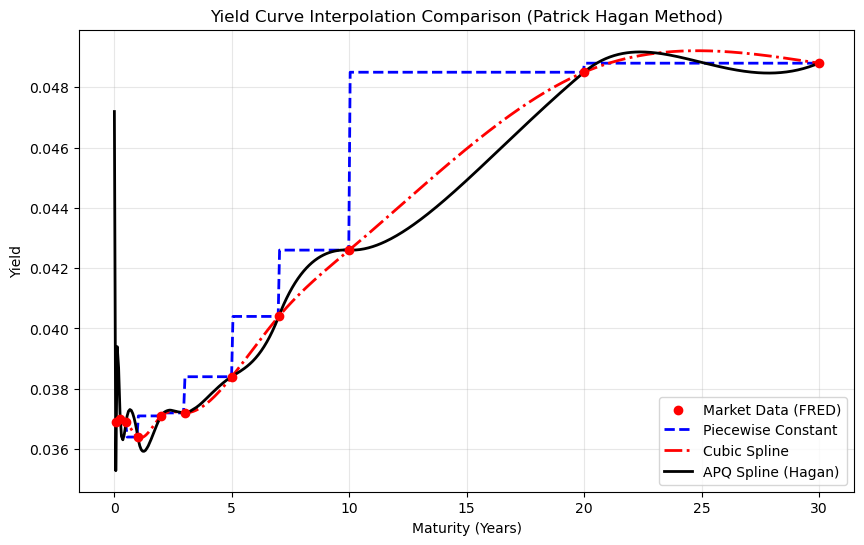

In [14]:
# Prepare Data (Assumes treasury_data from previous step)
# Convert yield to decimal for calculation (e.g., 4.5% -> 0.045)
maturities = treasury_data['Maturity'].values
yields = treasury_data['Yield'].values / 100.0

# Instantiate and Generate Curves
curve_builder = YieldCurve(maturities, yields)
t_range = np.linspace(0, 30, 500)

methods = {
    'Piecewise Constant': ('piecewise', 'blue', '--'),
    'Cubic Spline': ('cubic', 'red', '-.'),
    'APQ Spline (Hagan)': ('apqs', 'black', '-')
}

plt.figure(figsize=(10, 6))
plt.scatter(maturities, yields, color='red', label='Market Data (FRED)', zorder=5)

for label, (m, color, style) in methods.items():
    f_interp = curve_builder.get_interpolation(method=m)
    plt.plot(t_range, f_interp(t_range), label=label, color=color, linestyle=style, lw=2)

plt.title("Yield Curve Interpolation Comparison (Patrick Hagan Method)")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Part 2 Calibrate and Simulate Interest Rate Paths

### Interface Documentation: Part 1 to Part 2

### 1. Initialize YieldCurve
curve = YieldCurve(maturities, yields)
#### method options: 'apqs' (recommended), 'cubic', 'piecewise'

### 2. Available interfaces from Part 2

#### Instantaneous forward rate f(0,t) — used to compute θ(t)
f = curve.get_forward_rate(t, method='apqs')

### Initial short rate r(0) — starting point for simulation
r0 = curve.get_forward_rate(np.array([1e-6]), method='apqs')[0]

### Discount factor P(0,T) — only needed if you are calibrating a and sigma from market data
P = curve.get_discount_factor(t, method='apqs')

### 3. Pass into your HullWhiteModel
hw = HullWhiteModel(curve, a=..., sigma=..., method='apqs')

### 1. Interface from Part 1

In [16]:
maturities = treasury_data["Maturity"].values
yields = treasury_data["Yield"].values / 100

curve = YieldCurve(maturities, yields)
method = "apqs"  #alternatives: 'cubic', 'piecewise'

t_curve = np.linspace(0.001, 30, 500)
f0t = curve.get_forward_rate(t_curve, method=method)
P0T = curve.get_discount_factor(t_curve, method=method)
r0 = curve.get_forward_rate(np.array([1e-6]), method=method)[0]

print("Initial short rate r(0):", r0)
print("Example forward rate f(0,5):", curve.get_forward_rate(np.array([5]), method=method)[0])
print("Example discount factor P(0,10):", curve.get_discount_factor(np.array([10]), method=method)[0])


Initial short rate r(0): 0.04719489686590066
Example forward rate f(0,5): 0.040855548979758925
Example discount factor P(0,10): 0.65311579220066


### 2. 2-Factor Hull-White Model

In [17]:
#Model specification:
# r(t) = x(t) + y(t) + phi(t)
# dx(t) = -a x(t) dt + sigma dW1(t)
# dy(t) = -b y(t) dt + eta dw2(t)
# corr(dW1, dW2) = rho

class HullWhiteModel:
    def __init__(self, yield_curve, a: float, b: float, sigma: float, eta: float, rho: float, method: str = 'apqs'):
        """
        yield_curve: YieldCurve object from Part 1
        Initialize the 2-factor Hull-White model with the given yield curve,
        mean reversion speeds a and b, volatilities sigma and eta,
        correlation rho, and interpolation method.
        """
        self.curve = yield_curve
        self.a = a
        self.b = b
        self.sigma = sigma
        self.eta = eta
        self.rho = rho
        self.method = method


    def f0(self, t):
        """
        Initial instantaneous forward rate f(0,t) from yield curve
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        return self.curve.get_forward_rate(t, method=self.method)

    def phi(self, t):
        """
        Deterministic shift phi(t)

        phi(t) = f(0,t)
                 + (sigma^2 / (2a^2)) * (1 - e^{-at})^2
                 + (eta^2   / (2b^2)) * (1 - e^{-bt})^2
                 + (rho*sigma*eta/(ab)) * (1 - e^{-at})(1 - e^{-bt})
        """
        t = np.atleast_1d(np.asarray(t, dtype=float))
        
        term1 = (self.sigma ** 2 / (2 * self.a ** 2)) * (1 - np.exp(-self.a * t)) ** 2
        term2 = (self.eta ** 2   / (2 * self.b ** 2)) * (1 - np.exp(-self.b * t)) ** 2
        term3 = (self.rho * self.sigma * self.eta / (self.a * self.b)) \
                * (1 - np.exp(-self.a * t)) * (1 - np.exp(-self.b * t))

        return self.f0(t) + term1 + term2 + term3


    def simulate(self, T: float, n_steps: int, n_paths: int, seed: int = None):
        """
        Simulate the two latent factors x(t), y(t), then construct
            r(t) = x(t) + y(t) +phi(t) 
        using Euler.
        """
        if seed is not None:
            np.random.seed(seed)
        
        dt = T / n_steps
        sqrt_dt = np.sqrt(dt)
        t_grid = np.linspace(0, T, n_steps + 1)

        x_paths = np.zeros((n_paths, n_steps + 1))
        y_paths = np.zeros((n_paths, n_steps + 1))
        rates = np.zeros((n_paths, n_steps + 1))

        #Correlated Brownian shocks
        z1 = np.random.normal(size=(n_paths, n_steps))
        z2_indep = np.random.normal(size=(n_paths, n_steps))
        z2 = self.rho * z1 + np.sqrt(1 - self.rho ** 2) * z2_indep

        phi_grid = self.phi(t_grid)

        #Initial short rate from the initial forward curve
        r0 = curve.get_forward_rate(np.array([1e-6]), method=method)[0]

        #Initial conditions
        x_paths[:, 0] = 0
        y_paths[:, 0] = 0
        rates[:, 0] = r0 


        for i in range(n_steps):
            x_paths[:, i + 1] = (x_paths[:, i] + (-self.a * x_paths[:, i]) * dt 
                                 + self.sigma * sqrt_dt * z1[:, i])

            y_paths[:, i + 1] = (y_paths[:, i] + (-self.b * y_paths[:, i]) * dt 
                                 + self.eta * sqrt_dt * z2[:, i])
            
            rates[:, i + 1] = x_paths[:, i + 1] + y_paths[:, i + 1] + phi_grid[i + 1]
         
        
        return rates, x_paths, y_paths, t_grid

In [18]:
# Example parameters

a = 0.5        # faster mean reversion factor
b = 0.08       # slower mean reversion factor
sigma = 0.015  # volatility
eta = 0.008    # volatility
rho = -0.7     #correlation between factor shocks

hw = HullWhiteModel(curve, a=a, b=b, sigma=sigma, eta=eta, rho=rho, method=method)

### 3. Simulate Short-Rate Paths

In [19]:
T_sim = 10
n_steps = 500
n_paths = 1000

rates, x_paths, y_paths, t_grid = hw.simulate(T=T_sim, n_steps=n_steps, n_paths=n_paths, seed=42)

print("rates shape:", rates.shape)
print("x_paths shape:", x_paths.shape)
print("y_paths shape:", y_paths.shape)
print("t_grid shape:", t_grid.shape)

rates shape: (1000, 501)
x_paths shape: (1000, 501)
y_paths shape: (1000, 501)
t_grid shape: (501,)


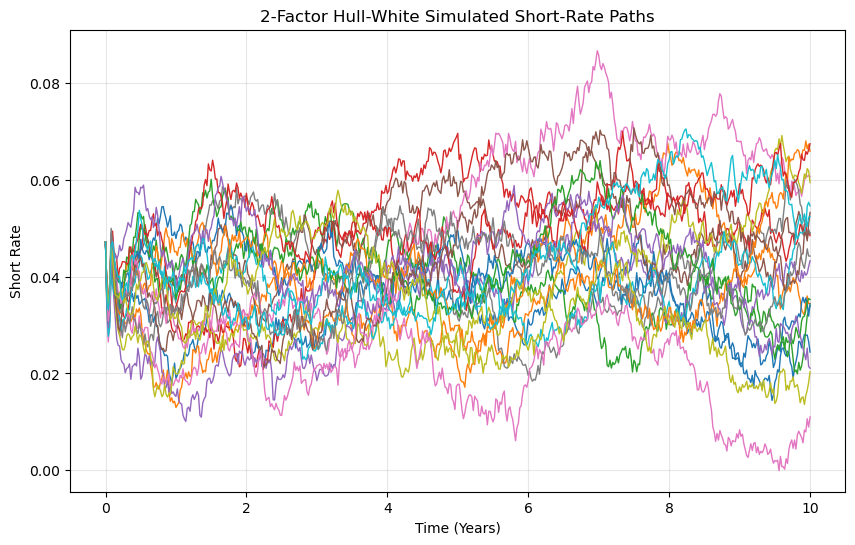

In [20]:
# Plot simulated short-rate paths

plt.figure(figsize=(10, 6))
for i in range(20):
    plt.plot(t_grid, rates[i], lw=1)

plt.title("2-Factor Hull-White Simulated Short-Rate Paths")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.grid(True, alpha=0.3)
plt.show()

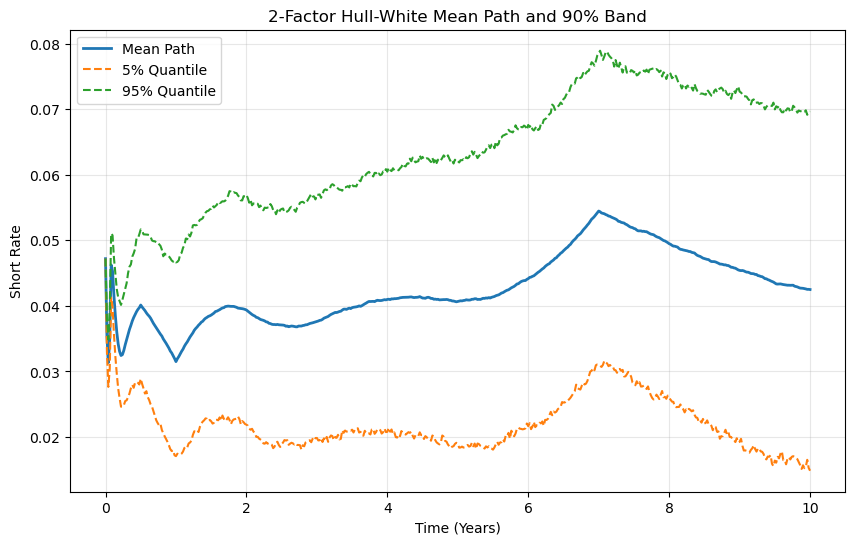

In [21]:
mean_path = rates.mean(axis=0)
q05 = np.quantile(rates, 0.05, axis=0)
q95 = np.quantile(rates, 0.95, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(t_grid, mean_path, label="Mean Path", lw=2)
plt.plot(t_grid, q05, linestyle="--", label="5% Quantile")
plt.plot(t_grid, q95, linestyle="--", label="95% Quantile")
plt.title("2-Factor Hull-White Mean Path and 90% Band")
plt.xlabel("Time (Years)")
plt.ylabel("Short Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
n_paths, n_times = rates.shape

short_rate_df = pd.DataFrame({"path_id": np.repeat(np.arange(n_paths), n_times),
                              "time_years": np.tile(t_grid, n_paths),
                              "month": np.tile(np.round(t_grid * 12).astype(int), n_paths),
                              "short_rate": rates.reshape(-1)})

short_rate_df

#what we need: 2 years,3 years, 5 years, 7 years, 10 years 
#how far we proejct: try 2 1 year, 2 year, 3 year. 

,path_id,time_years,month,short_rate
0,0,0.00,0,0.047195
1,0,0.02,0,0.035198
2,0,0.04,0,0.030258
3,0,0.06,1,0.035296
4,0,0.08,1,0.048984
...,...,...,...,...
500995,999,9.92,119,0.031849
500996,999,9.94,119,0.031979
500997,999,9.96,120,0.031757
500998,999,9.98,120,0.032081


In [66]:
short_rate_df

,path_id,time_years,month,short_rate
0,0,0.00,0,0.047195
1,0,0.02,0,0.035198
2,0,0.04,0,0.030258
3,0,0.06,1,0.035296
4,0,0.08,1,0.048984
...,...,...,...,...
500995,999,9.92,119,0.031849
500996,999,9.94,119,0.031979
500997,999,9.96,120,0.031757
500998,999,9.98,120,0.032081


### Part 3 Model Nonlinear Prepayment Behavior under changing interest rate conditions

In [ ]:
import pandas as pd
# Replace 'path_to_file.xlsx' with your actual file path
df = pd.read_excel('/Users/sangpark/Downloads/FRE_DPR_Cumulative.xlsx')
df['CPR'] #



/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


0         0.889
1         0.576
2         0.739
3         0.381
4         0.357
          ...  
450354    0.000
450355    0.000
450356    0.000
450357    0.000
450358    0.000
Name: CPR, Length: 450359, dtype: float64

In [136]:
#data to use: 
short_rate_df

,path_id,time_years,month,short_rate
0,0,0.00,0,0.047195
1,0,0.02,0,0.035198
2,0,0.04,0,0.030258
3,0,0.06,1,0.035296
4,0,0.08,1,0.048984
...,...,...,...,...
500995,999,9.92,119,0.031849
500996,999,9.94,119,0.031979
500997,999,9.96,120,0.031757
500998,999,9.98,120,0.032081


In [137]:
# testing: 
df['CPR']

0         0.889
1         0.576
2         0.739
3         0.381
4         0.357
          ...  
450354    0.000
450355    0.000
450356    0.000
450357    0.000
450358    0.000
Name: CPR, Length: 450359, dtype: float64

In [138]:
#Converting SMM into CPR. 
df['SMM_calc'] = (df['Unscheduled Principal Reduction Amount'] / df['Cohort Current UPB'])
df['CPR_calc'] = (1-(1-(df['SMM_calc']))**12)
#df['CPR_calc'] *=100 #empircal cpr

#data testing
(df['CPR_calc'] == 0).sum()
(df['CPR_calc'] == 0).mean()
df[df['CPR_calc'] == 0].iloc[0]
df[df['CPR_calc'] == 0].head() #boolean mask and filter rows.


,Type of Security,Year,WA Net Interest Rate,Cohort Current UPB,Cohort WA Current Interest Rate,Cohort WA Current Remaining Months to Maturity,Cohort WA Current Loan Age,Date,Factor Date,Principal Reduction Amount,Cumulative Principal Reduction Amount,Unscheduled Principal Reduction Amount,Cumulative Unscheduled Principal Reduction Amount,SMM,Cumulative SMM,CPR,Cumulative CPR,SMM_calc,CPR_calc
2663,Super-Conforming > 15yr,2016,3,4.479786e+09,3.735,327,29,01/08/2019,02/2019,2149.53,1152420.78,0.0,1148283.98,0.0,0.000257,0.0,0.308,0.0,0.0
2859,Other Fixed-Rate > 15yr,2013,3,1.335491e+09,3.664,245,70,01/25/2019,02/2019,604.53,2597520.80,0.0,2585426.37,0.0,0.001942,0.0,2.306,0.0,0.0
5085,20yr TBA Eligible,2014,3,6.340719e+08,3.813,182,53,02/26/2019,03/2019,41.68,1527437.46,0.0,1519191.56,0.0,0.002406,0.0,2.849,0.0,0.0
5886,15yr TBA Eligible,2018,2.5,8.006170e+08,3.267,164,12,02/08/2019,03/2019,2987.77,557448.14,0.0,551829.55,0.0,0.000693,0.0,0.828,0.0,0.0
7129,30yr TBA Eligible,2005,4.5,5.964111e+08,5.251,184,164,03/27/2019,04/2019,181.15,3131017.39,0.0,3116060.22,0.0,0.005243,0.0,6.113,0.0,0.0


In [139]:
#the 5th percentile range of values are close to 0 and not that valuluable distribution of prepayments and skewed to provide correct prepayment data.

df['CPR'].mean()
from scipy.stats.mstats import winsorize
import pandas as pd
# Example: Winsorize at the 5th and 95th percentiles
df['CPR_calc'] = winsorize(df['CPR_calc'], limits=[0.20, 0])

df['CPR_calc'].mean()
df['CPR_calc'].nsmallest(10)
df = df[df['CPR_calc'] >= 0.02] #keep only higher than 2 percent of the data.

In [141]:
#data checking. 
print(df['CPR_calc'].nsmallest(10))

76886     0.020000
132461    0.020001
71246     0.020003
184772    0.020003
29715     0.020003
90953     0.020003
115549    0.020003
132719    0.020004
101950    0.020004
73765     0.020005
Name: CPR_calc, dtype: float64


In [142]:
len(df['CPR_calc'])
df['CPR_calc'].mean()


0.02968958112835437

In [72]:
#data retesting if any NA exists. 
#data testing
(df['CPR_calc'] == 0).sum()
(df['CPR_calc'] == 0).mean()
df[df['CPR_calc'] == 0].iloc[0]
df[df['CPR_calc'] == 0].head() #boolean mask and filter rows.

IndexError: single positional indexer is out-of-bounds

In [143]:
#isthere any row with CPR = 0? 
df[df['CPR_calc']==0].iloc[0]
#none

IndexError: single positional indexer is out-of-bounds

In [144]:
len(df['CPR_calc'])
#data testing: 
df[df['CPR']==0].iloc[0]
#CPR is 0, since no prepayment was made at this factor date. however, we see CPR cumulative as 30 percent meaning prepayment made 30 percent so far of original balance.

#refinance incentive:

IndexError: single positional indexer is out-of-bounds

In [145]:

df['refinancing incentive_calc'] = (df['Cohort WA Current Interest Rate']/100) - 0.06

In [152]:
#data checking.
df['refinancing incentive_calc'].mean()
df['Cohort WA Current Loan Age'].mean()
scohort_view = df[[
    'Cohort WA Current Loan Age',
    'Cohort WA Current Interest Rate',
    'Cohort Current UPB'
]].drop_duplicates().reset_index(drop=True)
(df['CPR_calc'] == 0).sum()

0

In [153]:
df['age_bucket'] = pd.cut(
    df['Cohort WA Current Loan Age'],
    bins=[0, 60, 120, 180, 240, 360],
    labels=['0-5y','5-10y','10-15y','15-20y','20y+']
)
grouped = df.groupby('age_bucket')
CPR_min_age = grouped.apply(
    lambda x: x[x['refinancing incentive_calc'] < -0.005]['CPR_calc']
)
CPR_max_age = grouped.apply(
    lambda x: x[x['refinancing incentive_calc'] > 0.01]['CPR_calc'].mean()
)

/var/folders/1l/78zmsh7s0zvf4qbbcqrxk_5r0000gn/T/ipykernel_92748/2868260980.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('age_bucket')
/var/folders/1l/78zmsh7s0zvf4qbbcqrxk_5r0000gn/T/ipykernel_92748/2868260980.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  CPR_min_age = grouped.apply(
/var/folders/1l/78zmsh7s0zvf4qbbcqrxk_5r0000gn/T/ipykernel_92748/2868260980.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and 

In [154]:
CPR_min_age.value_counts()
df.dtypes

Type of Security                                       object
Year                                                    int64
WA Net Interest Rate                                   object
Cohort Current UPB                                    float64
Cohort WA Current Interest Rate                       float64
Cohort WA Current Remaining Months to Maturity          int64
Cohort WA Current Loan Age                              int64
Date                                                   object
Factor Date                                            object
Principal Reduction Amount                            float64
Cumulative Principal Reduction Amount                 float64
Unscheduled Principal Reduction Amount                float64
Cumulative Unscheduled Principal Reduction Amount     float64
SMM                                                   float64
Cumulative SMM                                        float64
CPR                                                   float64
Cumulati

In [155]:
monthly = df.groupby([
    'Cohort WA Current Remaining Months to Maturity',
    'Factor Date'
]).agg({
    'CPR_calc': 'mean',
    'SMM_calc': 'mean',
    'Cohort WA Current Interest Rate': 'first',
    'Cohort Current UPB': 'first'
}).reset_index()

In [79]:
#low = df[df['refinancing incentive_calc'] < -0.005]['CPR_calc']
#high = df[df['refinancing incentive_calc'] > 0.01]['CPR_calc']
#CPR_min = low.mean()
#CPR_max = high.mean()
#print(CPR_min, CPR_max)

In [80]:
#there are two strategies to design min CPR and max CPR. from incentives to quantile range. for now we do quantile range.
#q20 = df['refinancing incentive_calc'].quantile(0.2) #isit right to have / use 20 quantile and 80 quantile?
#q80 = df['refinancing incentive_calc'].quantile(0.8)

#df['CPR_min'] = df[df['refinancing incentive_calc'] <= q20]['CPR_calc'].mean()
#df['CPR_max'] = df[df['refinancing incentive_calc'] >= q80]['CPR_calc'].mean()

#print(CPR_min, CPR_max)

In [156]:
low = df[df['refinancing incentive_calc'] < -0.005]['CPR_calc']
high = df[df['refinancing incentive_calc'] > 0.01]['CPR_calc']
CPR_min = low.mean()
CPR_max = high.mean()
print(CPR_min, CPR_max)


#there are two strategies to design min CPR and max CPR. from incentives to quantile range. for now we do quantile range.
q20 = df['refinancing incentive_calc'].quantile(0.2) #isit right to have / use 20 quantile and 80 quantile?
q80 = df['refinancing incentive_calc'].quantile(0.8)

df['CPR_min'] = df[df['refinancing incentive_calc'] <= q20]['CPR_calc'].mean()
df['CPR_max'] = df[df['refinancing incentive_calc'] >= q80]['CPR_calc'].mean()

print(CPR_min, CPR_max)

0.029948783451091494 0.027129843827757523
0.029948783451091494 0.027129843827757523


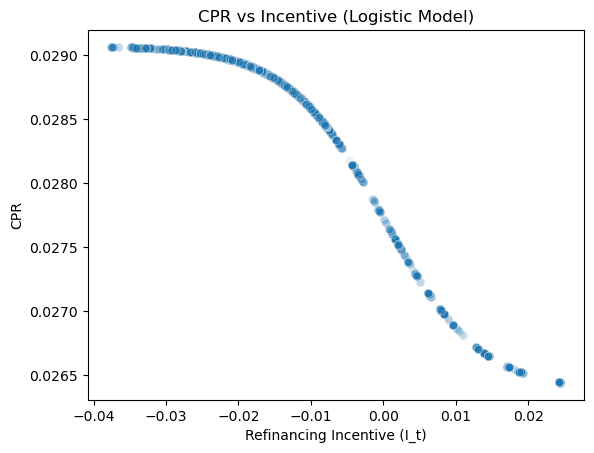

In [157]:
#visual graph: 
import numpy as np
import matplotlib.pyplot as plt
k = 150      # steepness (tune later)
theta = 0   # midpoint

df['CPR_model'] = df['CPR_min'] + (
    (df['CPR_max'] - df['CPR_min']) *
    (1 / (1 + np.exp(-k * (df['refinancing incentive_calc'] - theta))))
)
df['SMM_model'] = 1 - (1 - df['CPR_model'])**(1/12)
df[['CPR_min', 'CPR_model', 'CPR_max']].head()

import seaborn as sns

sns.scatterplot(
    x='refinancing incentive_calc',
    y='CPR_model',
    data=df,
    alpha=0.1
)
plt.xlabel('Refinancing Incentive (I_t)')
plt.ylabel('CPR')
plt.title('CPR vs Incentive (Logistic Model)')
plt.show()


In [158]:
import numpy as np
from scipy.optimize import curve_fit
#might have to use logistic curve for instead of truncating the data.

In [159]:
fit_df = df[['refinancing incentive_calc', 'CPR_calc']].dropna().copy()
x = fit_df['refinancing incentive_calc'].values
y = fit_df['CPR_calc'].values

k_fixed = 30
theta_fixed = 0.0

def logistic_cpr_fixed(I, cpr_min, cpr_max):
    return cpr_min + (cpr_max - cpr_min) / (1 + np.exp(-k_fixed * (I - theta_fixed)))

params, cov = curve_fit(
    logistic_cpr_fixed,
    x,
    y,
    p0=[y.min(), y.max()],
    bounds=([0.0, 0.0], [1.0, 1.0]),
    maxfev=20000
)
cpr_min_hat, cpr_max_hat = params
print("CPR_min =", cpr_min_hat)
print("CPR_max =", cpr_max_hat)

df['CPR_model'] = logistic_cpr_fixed(df['refinancing incentive_calc'], cpr_min_hat, cpr_max_hat)
df['SMM_model'] = 1 - (1 - df['CPR_model'])**(1/12)

CPR_min = 0.035036471253435696
CPR_max = 0.020705913270443195


In [160]:
#make min and max as distribution, not deterministic but using Monte Carlo Sampling Method. 
def draw_cpr_bounds(df, q20, q80):
    low = df[df['refinancing incentive_calc'] <= q20]['CPR_calc'].dropna().values
    high = df[df['refinancing incentive_calc'] >= q80]['CPR_calc'].dropna().values
    cpr_min_s = np.mean(np.random.choice(low, size=len(low), replace=True))
    cpr_max_s = np.mean(np.random.choice(high, size=len(high), replace=True))

    # enforce ordering
    cpr_min_s, cpr_max_s = min(cpr_min_s, cpr_max_s), max(cpr_min_s, cpr_max_s)
    return cpr_min_s, cpr_max_s

def simulate_cpr_path_full(I_path, df, q20, q80):
    # draw random bounds
    cpr_min_s, cpr_max_s = draw_cpr_bounds(df, q20, q80)

    # logistic mean with random bounds
    cpr_mean = cpr_min_s + (cpr_max_s - cpr_min_s) / (
        1 + np.exp(-k_hat * (I_path - theta_hat))
    )

    # residual noise
    residuals = df['residual'].dropna().values
    eps = np.random.choice(residuals, size=len(I_path), replace=True)

    cpr_sim = cpr_mean + eps
    cpr_sim = np.clip(cpr_sim, 0, 1)

    return cpr_sim
#testing to simulate the path.
for i in range(5):
    cpr_min_s, cpr_max_s = draw_cpr_bounds(df, q20, q80)
    print(i, cpr_min_s, cpr_max_s)
mins = []
maxs = []
for _ in range(1000):
    cpr_min_s, cpr_max_s = draw_cpr_bounds(df, q20, q80)
    mins.append(cpr_min_s)
    maxs.append(cpr_max_s)
mins = np.array(mins)
maxs = np.array(maxs)
print("CPR_min mean:", mins.mean())
print("CPR_min std :", mins.std())
print("CPR_min 5/95:", np.percentile(mins, [5, 95]))
print("CPR_max mean:", maxs.mean())
print("CPR_max std :", maxs.std())
print("CPR_max 5/95:", np.percentile(maxs, [5, 95]))

0 0.026216334040618336 0.02919092316195511
1 0.026343336377983972 0.02893933429821616
2 0.026205446111425678 0.029093339266558077
3 0.02626514395237883 0.02883733679999811
4 0.0264730123459687 0.02909049085711283
CPR_min mean: 0.026374894495122824
CPR_min std : 9.673336743481483e-05
CPR_min 5/95: [0.02621989 0.02653819]
CPR_max mean: 0.02906998468374541
CPR_max std : 0.00011961634992925358
CPR_max 5/95: [0.0288776  0.02926767]


In [100]:
df['CPR_calc'].nlargest(30)
df['CPR_calc'].nsmallest(30)

76886     0.020000
132461    0.020001
71246     0.020003
184772    0.020003
29715     0.020003
90953     0.020003
115549    0.020003
132719    0.020004
101950    0.020004
73765     0.020005
114026    0.020005
122456    0.020006
66024     0.020006
63027     0.020008
90328     0.020008
149096    0.020008
142278    0.020009
100338    0.020009
146632    0.020009
129589    0.020009
66804     0.020009
371024    0.020009
121557    0.020009
85488     0.020010
135711    0.020010
139811    0.020010
97227     0.020010
154011    0.020011
137613    0.020011
142640    0.020012
Name: CPR_calc, dtype: float64

In [161]:
def draw_cpr_bounds_from_cpr(df, lower_q=0.2, upper_q=0.8):
    # define tails directly from CPR distribution

    cpr = df['CPR_calc'].dropna().values 
    #assign the threshold first.
    low = cpr[cpr <= np.quantile(cpr, lower_q)]  #converts pandas object into numpy arrays.
    high = cpr[cpr >= np.quantile(cpr, upper_q)]
    # enforce ordering
    # define tails directly from CPR distribution

    # bootstrap means / bootstrap resampling method. creates code to select list of simulations
    # as low to max through randomized selections from the list of integers/ decimals from the list.
    cpr_min_s = np.mean(np.random.choice(low, size=len(low), replace=True))
    cpr_max_s = np.mean(np.random.choice(high, size=len(high), replace=True))
    # runs through error testing.

    cpr_min_s, cpr_max_s = min(cpr_min_s, cpr_max_s), max(cpr_min_s, cpr_max_s)

    return cpr_min_s, cpr_max_s


In [162]:
def simulate_cpr_path_full(I_path, df):
    # draw bounds from CPR distribution (not incentive)
    cpr_min_s, cpr_max_s = draw_cpr_bounds_from_cpr(df)

    # logistic CPR path
    cpr_mean = cpr_min_s + (cpr_max_s - cpr_min_s) / (
        1 + np.exp(-k_hat * (I_path - theta_hat))
    )

    # residual noise
    residuals = df['residual'].dropna().values
    eps = np.random.choice(residuals, size=len(I_path), replace=True)

    cpr_sim = cpr_mean + eps
    cpr_sim = np.clip(cpr_sim, 0, 1)

    return cpr_sim

In [163]:
mins, maxs = [], []

for _ in range(1000):
    cpr_min_s, cpr_max_s = draw_cpr_bounds_from_cpr(df)
    mins.append(cpr_min_s)
    maxs.append(cpr_max_s)

mins = np.array(mins)
maxs = np.array(maxs)

print("CPR_min mean:", mins.mean())
print("CPR_min std :", mins.std())
print("CPR_min 5/95:", np.percentile(mins, [5, 95]))

print("CPR_max mean:", maxs.mean())
print("CPR_max std :", maxs.std())
print("CPR_max 5/95:", np.percentile(maxs, [5, 95]))

#CPR min: ~2%, CPR max ~5%


CPR_min mean: 0.02097507366740809
CPR_min std : 8.322110116916735e-06
CPR_min 5/95: [0.02096101 0.02098939]
CPR_max mean: 0.0463314527006688
CPR_max std : 0.00015042727989951854
CPR_max 5/95: [0.04608058 0.04656819]


In [164]:
#next data we have proejcted short_rate and paths. 
short_rate_df

,path_id,time_years,month,short_rate
0,0,0.00,0,0.047195
1,0,0.02,0,0.035198
2,0,0.04,0,0.030258
3,0,0.06,1,0.035296
4,0,0.08,1,0.048984
...,...,...,...,...
500995,999,9.92,119,0.031849
500996,999,9.94,119,0.031979
500997,999,9.96,120,0.031757
500998,999,9.98,120,0.032081


In [165]:
df['WA Net Interest Rate']

1684        4
2661        4
3010        4
3180      4.5
3196        4
         ... 
450271    5.5
450277    5.5
450278    5.5
450279    5.5
450283    5.5
Name: WA Net Interest Rate, Length: 25417, dtype: object

In [166]:
df

,Type of Security,Year,WA Net Interest Rate,Cohort Current UPB,Cohort WA Current Interest Rate,Cohort WA Current Remaining Months to Maturity,Cohort WA Current Loan Age,Date,Factor Date,Principal Reduction Amount,...,CPR,Cumulative CPR,SMM_calc,CPR_calc,refinancing incentive_calc,age_bucket,CPR_min,CPR_max,CPR_model,SMM_model
1684,20yr TBA Eligible,2014,4,1.095510e+09,4.628,180,55,01/31/2019,02/2019,1946491.12,...,2.112,8.482,0.001770,0.021036,-0.01372,0-5y,0.029073,0.026371,0.029325,0.002477
2661,Super-Conforming > 15yr,2015,4,6.778993e+08,4.672,314,42,02/04/2019,02/2019,1642068.26,...,2.869,6.747,0.002419,0.028640,-0.01328,0-5y,0.029073,0.026371,0.029280,0.002473
3010,RPL,2010,4,5.198485e+08,4.391,315,99,02/04/2019,02/2019,1016605.45,...,2.323,7.425,0.001953,0.023186,-0.01609,5-10y,0.029073,0.026371,0.029568,0.002498
3180,ARM,2006,4.5,1.196428e+09,4.981,211,149,02/01/2019,02/2019,2430441.27,...,2.410,19.470,0.002025,0.024036,-0.01019,10-15y,0.029073,0.026371,0.028958,0.002446
3196,ARM,2007,4,6.973083e+08,4.657,219,141,01/28/2019,02/2019,1310196.21,...,2.232,15.090,0.001873,0.022251,-0.01343,10-15y,0.029073,0.026371,0.029295,0.002475
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450271,ARM,2025,5.5,1.955388e+09,6.083,353,7,03/12/2026,04/2026,5296150.45,...,3.203,9.757,0.002706,0.031991,0.00083,0-5y,0.029073,0.026371,0.027782,0.002345
450277,ARM,2025,5.5,1.955388e+09,6.083,353,7,03/18/2026,04/2026,3438237.63,...,2.089,16.861,0.001757,0.020876,0.00083,0-5y,0.029073,0.026371,0.027782,0.002345
450278,ARM,2025,5.5,1.955388e+09,6.083,353,7,03/19/2026,04/2026,4729872.57,...,2.864,19.279,0.002417,0.028616,0.00083,0-5y,0.029073,0.026371,0.027782,0.002345
450279,ARM,2025,5.5,1.955388e+09,6.083,353,7,03/20/2026,04/2026,5521625.75,...,3.337,22.020,0.002821,0.033331,0.00083,0-5y,0.029073,0.026371,0.027782,0.002345


In [176]:
df['cleaned_WA Net Interest Rate']= df['WA Net Interest Rate'].astype(str)
#data cleaning process. some are written as words for the issued rates of bonds. 
df['cleaned_WA Net Interest Rate'] = df['cleaned_WA Net Interest Rate'].str.extract(r'(\d+\.?\d*)').astype(float)
df['cleaned_WA Net Interest Rate'] = df['cleaned_WA Net Interest Rate'] / 100 #currently original rate in percentage convert dec for computation. 

In [177]:
df['cleaned_WA Net Interest Rate']

1684      0.040
2661      0.040
3010      0.040
3180      0.045
3196      0.040
          ...  
450271    0.055
450277    0.055
450278    0.055
450279    0.055
450283    0.055
Name: cleaned_WA Net Interest Rate, Length: 25417, dtype: float64

In [178]:
df['cleaned_WA Net Interest Rate'].isna().sum()

0

In [179]:
#for computation, we are simulating the refinance incenctive using It = c - rt where c is the issued coupon rate and rt is the simulated future rates from Whitehull model. 
coupon_list = np.sort(df['cleaned_WA Net Interest Rate'].dropna().unique()) #get unique list of issued coupon rate 
coupon_list

array([0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 , 0.045, 0.05 , 0.055,
       0.06 , 0.065, 0.07 , 0.075])

In [180]:
short_rate_df

,path_id,time_years,month,short_rate
0,0,0.00,0,0.047195
1,0,0.02,0,0.035198
2,0,0.04,0,0.030258
3,0,0.06,1,0.035296
4,0,0.08,1,0.048984
...,...,...,...,...
500995,999,9.92,119,0.031849
500996,999,9.94,119,0.031979
500997,999,9.96,120,0.031757
500998,999,9.98,120,0.032081


In [ ]:
import pandas as pd
import numpy as np

# unique coupon rates
coupon_list = np.sort(df['cleaned_WA Net Interest Rate'].dropna().unique())
# make a small dataframe of coupon rates
coupon_df = pd.DataFrame({'coupon_rate': coupon_list})
# cross join coupon rates with all short-rate rows
refi_df = coupon_df.merge(short_rate_df, hows='cross')
# compute refinance incentive
refi_df['refi_incentive'] = refi_df['coupon_rate'] - refi_df['short_rate']
refi_df = refi_df.sort_values(['coupon_rate', 'path_id', 'time_years']).reset_index(drop=True)
refi_df.head()
refi_df[(refi_df['coupon_rate'] == 0.065) & (refi_df['path_id'] == 0)].head(20)

,coupon_rate,path_id,time_years,month,short_rate,refi_incentive
5010000,0.065,0,0.00,0,0.047195,0.017805
5010001,0.065,0,0.02,0,0.035198,0.029802
5010002,0.065,0,0.04,0,0.030258,0.034742
5010003,0.065,0,0.06,1,0.035296,0.029704
5010004,0.065,0,0.08,1,0.048984,0.016016
5010005,0.065,0,0.10,1,0.047986,0.017014
5010006,0.065,0,0.12,1,0.043474,0.021526
5010007,0.065,0,0.14,2,0.042238,0.022762
5010008,0.065,0,0.16,2,0.039641,0.025359
5010009,0.065,0,0.18,2,0.038846,0.026154


In [183]:
#issued coupon range check 
coupon_list 

array([0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 , 0.045, 0.05 , 0.055,
       0.06 , 0.065, 0.07 , 0.075])

In [184]:
refi_df

,coupon_rate,path_id,time_years,month,short_rate,refi_incentive
0,0.015,0,0.00,0,0.047195,-0.032195
1,0.015,0,0.02,0,0.035198,-0.020198
2,0.015,0,0.04,0,0.030258,-0.015258
3,0.015,0,0.06,1,0.035296,-0.020296
4,0.015,0,0.08,1,0.048984,-0.033984
...,...,...,...,...,...,...
6512995,0.075,999,9.92,119,0.031849,0.043151
6512996,0.075,999,9.94,119,0.031979,0.043021
6512997,0.075,999,9.96,120,0.031757,0.043243
6512998,0.075,999,9.98,120,0.032081,0.042919


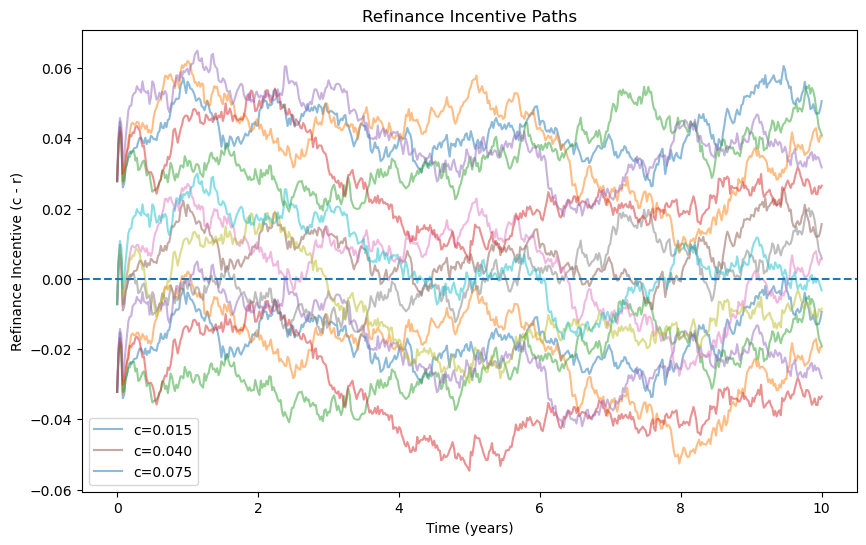

In [ ]:
import matplotlib.pyplot as plt

#Picking few issued rates to see their refinance interest simulationsl 
# 
# sample_coupons = coupon_list[[0, 5, -1]]  # low, mid, high

plt.figure(figsize=(10,6))

for c in sample_coupons:
    subset = refi_df[(refi_df['coupon_rate'] == c) & (refi_df['path_id'] < 5)]
    
    for pid in subset['path_id'].unique():
        path = subset[subset['path_id'] == pid]
        plt.plot(path['time_years'], path['refi_incentive'], alpha=0.5, label=f'c={c:.3f}' if pid==0 else "")

plt.axhline(0, linestyle='--')  # important reference line
plt.xlabel('Time (years)')
plt.ylabel('Refinance Incentive (c - r)')
plt.title('Refinance Incentive Paths')
plt.legend()
plt.show()

In [191]:
#Future conditional Prepayment Rate (CPR) projection using logistic function 
#so we are applying equation: CPR(t) = CPR_min + (CPR_max - CPR_min) / (1 + exp(-k*(I(t) - theta)))

cpr_min = mins.mean()
cpr_max = maxs.mean()
k_hat = 100     # steepness (you used this earlier)
theta_hat = 0   # midpoint
refi_df['CPR_proj'] = cpr_min + (cpr_max - cpr_min) / (
    1 + np.exp(-k_hat * (refi_df['refi_incentive'] - theta_hat))
)

In [192]:
cpr_min

0.02097507366740809

In [193]:
refi_df

,coupon_rate,path_id,time_years,month,short_rate,refi_incentive,CPR_proj
0,0.015,0,0.00,0,0.047195,-0.032195,0.021950
1,0.015,0,0.02,0,0.035198,-0.020198,0.023945
2,0.015,0,0.04,0,0.030258,-0.015258,0.025504
3,0.015,0,0.06,1,0.035296,-0.020296,0.023920
4,0.015,0,0.08,1,0.048984,-0.033984,0.021795
...,...,...,...,...,...,...,...
6512995,0.075,999,9.92,119,0.031849,0.043151,0.045997
6512996,0.075,999,9.94,119,0.031979,0.043021,0.045993
6512997,0.075,999,9.96,120,0.031757,0.043243,0.046000
6512998,0.075,999,9.98,120,0.032081,0.042919,0.045989


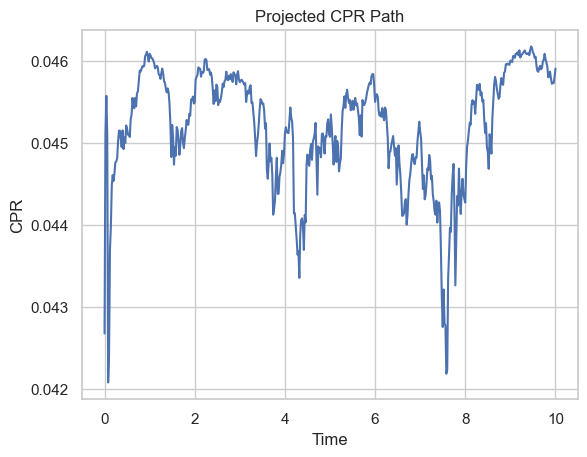

In [201]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# optional: nicer default style
sns.set(style="whitegrid")


sample = refi_df[(refi_df['coupon_rate'] == 0.065) & (refi_df['path_id'] == 0)]

plt.plot(sample['time_years'], sample['CPR_proj'])
plt.title("Projected CPR Path")
plt.xlabel("Time")
plt.ylabel("CPR")
plt.show()
#one example. other two examples. 

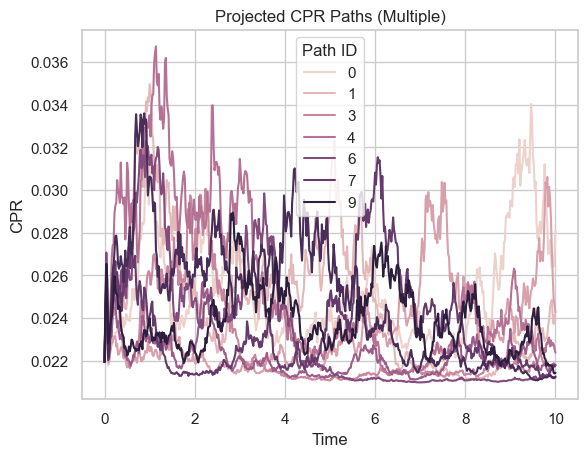

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

sample_multi = refi_df[
    (refi_df['coupon_rate'] == 0.015) &
    (refi_df['path_id'].isin([0, 1, 2,3,4,5,6,7,8,9]))
]
sns.lineplot(
    x='time_years',
    y='CPR_proj',
    hue='path_id',        # color by path
    data=sample_multi
)

plt.title("Projected CPR Paths (Multiple)")
plt.xlabel("Time")
plt.ylabel("CPR")
plt.legend(title="Path ID")
plt.show()

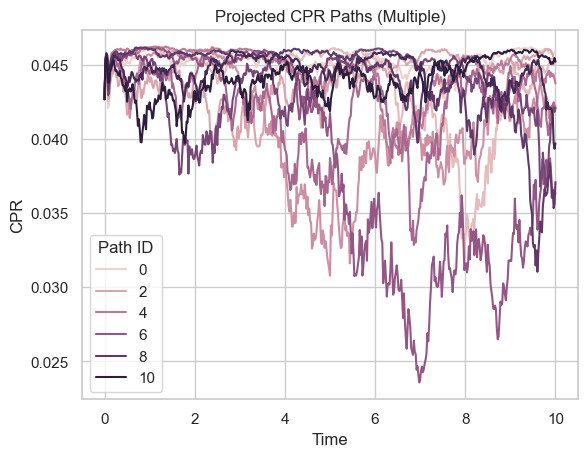

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

sample_multi = refi_df[
    (refi_df['coupon_rate'] == 0.065) &
    (refi_df['path_id'].isin([0, 1, 2,3,4,5,6,7,8,9,10]))
]
sns.lineplot(
    x='time_years',
    y='CPR_proj',
    hue='path_id',        # color by path
    data=sample_multi
)

plt.title("Projected CPR Paths (Multiple)")
plt.xlabel("Time")
plt.ylabel("CPR")
plt.legend(title="Path ID")
plt.show()

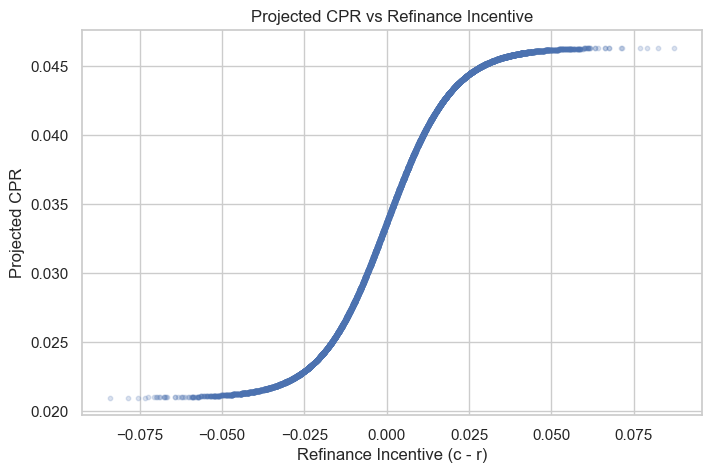

In [209]:
import matplotlib.pyplot as plt

sample = refi_df.sample(10000, random_state=42)  # smaller sample for plotting

plt.figure(figsize=(8,5))
plt.scatter(sample['refi_incentive'], sample['CPR_proj'], alpha=0.2, s=10)
plt.xlabel('Refinance Incentive (c - r)')
plt.ylabel('Projected CPR')
plt.title('Projected CPR vs Refinance Incentive')
plt.show()


Text(0.5, 0.92, '3D CPR Path | coupon=0.075, path=0')

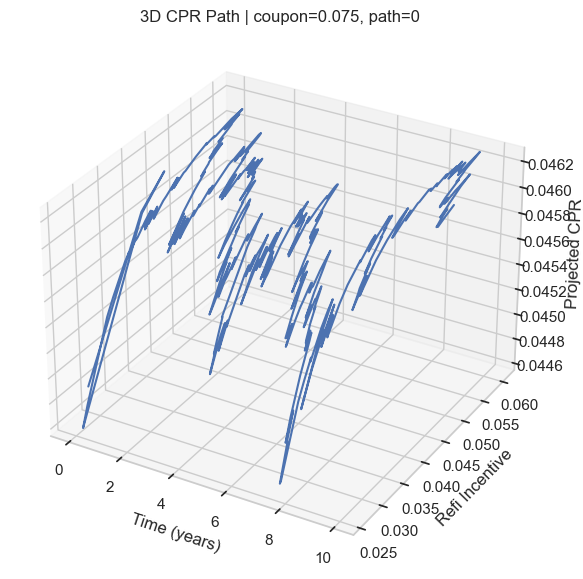

In [210]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# choose one coupon and one simulated path
c = 0.075
pid = 0

sample = refi_df[
    (refi_df['coupon_rate'] == c) &
    (refi_df['path_id'] == pid)
].sort_values('time_years')

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    sample['time_years'],
    sample['refi_incentive'],
    sample['CPR_proj']
)

ax.set_xlabel('Time (years)')
ax.set_ylabel('Refi Incentive')
ax.set_zlabel('Projected CPR')
ax.set_title(f'3D CPR Path | coupon={c:.3f}, path={pid}')


In [133]:
refi_df

,coupon_rate,path_id,time_years,month,short_rate,refi_incentive,CPR_proj
0,0.015,0,0.00,0,0.047195,-0.032195,0.021950
1,0.015,0,0.02,0,0.035198,-0.020198,0.023945
2,0.015,0,0.04,0,0.030258,-0.015258,0.025503
3,0.015,0,0.06,1,0.035296,-0.020296,0.023919
4,0.015,0,0.08,1,0.048984,-0.033984,0.021795
...,...,...,...,...,...,...,...
6512995,0.075,999,9.92,119,0.031849,0.043151,0.045991
6512996,0.075,999,9.94,119,0.031979,0.043021,0.045987
6512997,0.075,999,9.96,120,0.031757,0.043243,0.045994
6512998,0.075,999,9.98,120,0.032081,0.042919,0.045983


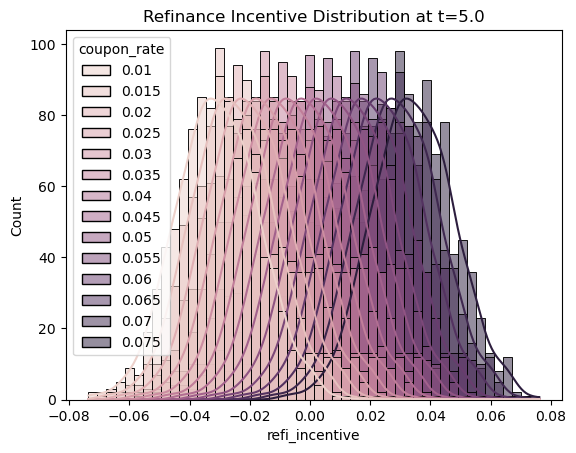

In [ ]:
#this one not that helpful. 
import seaborn as sns

# pick a time (e.g., 5 years)
t = 5.0

subset = refi_df[np.isclose(refi_df['time_years'], t)]

sns.histplot(data=subset, x='refi_incentive', hue='coupon_rate', bins=50, kde=True)
plt.title(f'Refinance Incentive Distribution at t={t}')
plt.show()

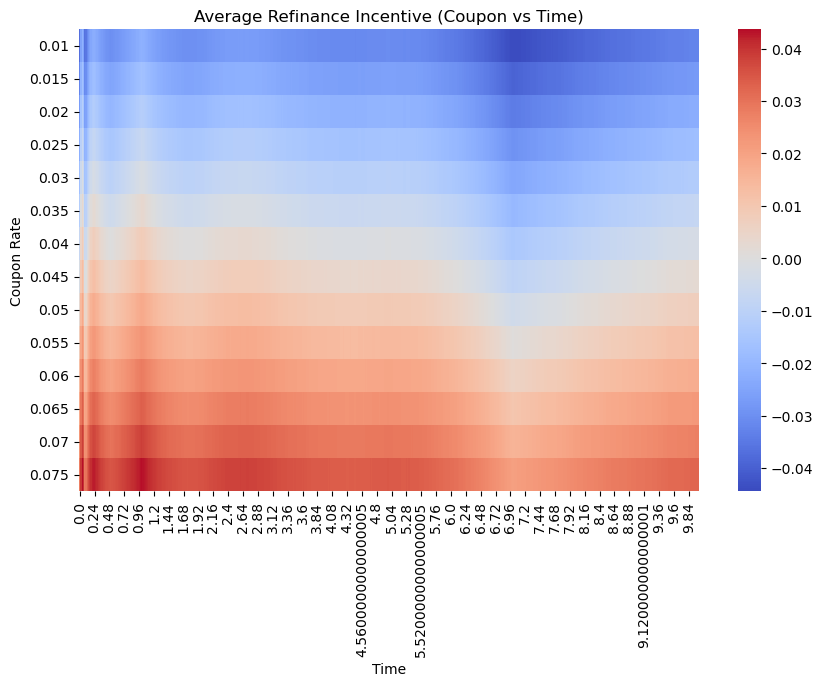

In [ ]:
#this one not that helpful 
pivot = refi_df.groupby(['coupon_rate', 'time_years'])['refi_incentive'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap='coolwarm', center=0)
plt.title('Average Refinance Incentive (Coupon vs Time)')
plt.xlabel('Time')
plt.ylabel('Coupon Rate')
plt.show()

In [ ]:
#we can probably compute back to find SMM amount for each of the CPR as well. 
#and compare with mortage calculator 
#simulaition variance reduction. 